# **Carga Inicial de librerías**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import pandas as pd
import seaborn as sns
from scipy import stats

# **Carga del Dataset y preparación de los datos**

In [5]:


#Definimos la URL del archivo CSV
url = "https://raw.githubusercontent.com/brunopless/TFM-Equipo-4-BDDS/main/entrega-3/df_bcn_imputado.csv"

#Leemos los datos directamente desde la URL
data = pd.read_csv(url)

#Mostramos las primeras filas del dataset para verificar que se cargó correctamente
print(data.head())

   Unnamed: 0  floor   price operation   size  exterior  rooms  bathrooms  \
0           1    4.0   749.0      rent   45.0         1      1          1   
1           2    2.0  4400.0      rent  170.0         1      3          4   
2           3    5.0  1700.0      rent   74.0         1      2          1   
3           4    1.0  2369.0      rent  127.0         1      2          2   
4           5    0.0  4000.0      rent   55.0         1      1          1   

    latitude  longitude  ...  numero_buenasmigas_cercanos_mas_de_cero  \
0  41.383719   2.175998  ...                                        1   
1  41.397182   2.142885  ...                                        0   
2  41.405040   2.211389  ...                                        0   
3  41.408746   2.215716  ...                                        0   
4  41.392297   2.169440  ...                                        0   

   numero_clubesnocturnos_cercanos_mas_de_cero  \
0                                            0  

# **Modelo Variable dependiente "price_m2"**

In [2]:


#Separamos variables independientes y variable dependiente
X = data[['floor', 'size', 'exterior', 'rooms', 'bathrooms', 'newDevelopment', 'hasLift', 'topNewDevelopment',
    'numero_bancos_cercanos', 'numero_starbucks_cercanos', 'numero_atractivos_cercanos', 'numero_buenasmigas_cercanos',
    'numero_clubesnocturnos_cercanos', 'numero_mcdonalds_cercanos', 'numero_metro_cercanos', 'numero_parking_cercanos',
    'numero_parkingbici_cercanos', 'numero_parques_cercanos', 'numero_playas_cercanos', 'numero_santagloria_cercanos',
    'numero_vivari_cercanos', 'num_airbnbs_500', 'media_precios_airbnbs_500',
    'propertyType_chalet', 'propertyType_duplex', 'propertyType_flat', 'propertyType_penthouse', 'status_good',
    'status_newdevelopment', 'num_airbnbs_500_mas_de_cero', 'media_precios_airbnbs_500_mas_de_cero',
    'numero_bancos_cercanos_mas_de_cero', 'numero_starbucks_cercanos_mas_de_cero', 'numero_atractivos_cercanos_mas_de_cero',
    'numero_buenasmigas_cercanos_mas_de_cero', 'numero_clubesnocturnos_cercanos_mas_de_cero', 'numero_mcdonalds_cercanos_mas_de_cero',
    'numero_metro_cercanos_mas_de_cero', 'numero_parking_cercanos_mas_de_cero', 'numero_parkingbici_cercanos_mas_de_cero',
    'numero_parques_cercanos_mas_de_cero', 'numero_playas_cercanos_mas_de_cero', 'numero_santagloria_cercanos_mas_de_cero',
    'numero_vivari_cercanos_mas_de_cero']]
y = data['price_m2']


## División datos para entrenamiento y prueba

In [3]:
from sklearn.model_selection import train_test_split

#Dividimos el dataset en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Escalamiento de variables y entrenamiento SVR

In [4]:
#Escalamiento de variables
from sklearn.preprocessing import StandardScaler

#Definimos el escalador
scaler = StandardScaler()

#Datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

#Datos de prueba
X_test_scaled = scaler.transform(X_test)

#Entrenamiento modelo SVR
from sklearn.svm import SVR

#Creamos el modelo SVR con el kernel RBF
svr_model = SVR(kernel='rbf')

#Entrenamos el modelo
svr_model.fit(X_train_scaled, y_train)

#Predicciones
#Predecimos los precios en los datos de prueba
y_pred = svr_model.predict(X_test_scaled)

## Evaluación del modelo

In [7]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import numpy as np


#Calculo de MSE
mse = mean_squared_error(y_test, y_pred)

#Calculamos el R²
r2 = r2_score(y_test, y_pred)

#Calculamos el R² ajustado
n = len(y_test)
p = X_test.shape[1]
r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Calculamos MAE
mae = mean_absolute_error(y_test, y_pred)

#Calculamos MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

#Suma de Residuos al Cuadrado (RSS)
rss = np.sum((y_test - y_pred) ** 2)

#Calculamos el AIC
aic = n * np.log(rss / n) + 2 * p

print(f'MSE : {mse}')
print(f'R² : {r2}')
print(f'R² ajustado : {r2_ajustado}')
print(f'MAE : {mae}')
print(f'MAPE : {mape:.2f}%')
print(f'AIC : {aic}')

MSE : 105.15048412578975
R² : 0.25271979838309355
R² ajustado : 0.24330659229344453
MAE : 7.190475700828856
MAPE : 24.85%
AIC : 16558.778687227725


## Ajuste de Hiperparametros

In [8]:
from sklearn.model_selection import GridSearchCV

#Definimos los parámetros a ajustar
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

#Crear el modelo de búsqueda utilizando un grid
grid = GridSearchCV(SVR(), param_grid, refit=True, verbose=2)

#Entrenamos el modelo para con de hiperparámetros
grid.fit(X_train_scaled, y_train)

#Mejor combinación de parámetros para el modelo
print(grid.best_params_)

#Selección del mejor modelo para hacer predicciones
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.8s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.8s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.6s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.6s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  10.4s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  10.6s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  11.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  10.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   9.3s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=  10.5s
[CV] END ......................C=0.1, gamma=0.01

In [9]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import numpy as np
from sklearn.model_selection import GridSearchCV
# Definir los parámetros a ajustar
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

#Creamos el modelo de búsqueda en cuadrícula
grid = GridSearchCV(SVR(), param_grid, refit=True, verbose=2)

#Entrenamos el modelo con búsqueda de hiperparámetros
grid.fit(X_train_scaled, y_train)

#Mejoramos combinación de parámetros
print("Mejores parámetros encontrados:", grid.best_params_)


best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

#Métricas
r2 = r2_score(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
mape = mean_absolute_percentage_error(y_test, y_pred_best)

#Calculamos el R2 ajustado
n = len(y_test)
p = X_test_scaled.shape[1]
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Calculamos AIC

rss = np.sum((y_test - y_pred_best) ** 2)
aic = n * np.log(rss / n) + 2 * p

# Imprimir métricas
print("R2:", r2)
print("R2 Ajustado:", r2_adj)
print("MAE:", mae)
print("MAPE:", mape)
print("AIC:", aic)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  14.7s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  13.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  13.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   9.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  10.4s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  10.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  10.3s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   9.9s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   9.8s
[CV] END ......................C=0.1, gamma=0.01

# **Modelo Variable dependiente "price"**

In [2]:
#Separamos variables independientes y variable dependiente
X = data[['floor', 'size', 'exterior', 'rooms', 'bathrooms', 'newDevelopment', 'hasLift', 'topNewDevelopment',
    'numero_bancos_cercanos', 'numero_starbucks_cercanos', 'numero_atractivos_cercanos', 'numero_buenasmigas_cercanos',
    'numero_clubesnocturnos_cercanos', 'numero_mcdonalds_cercanos', 'numero_metro_cercanos', 'numero_parking_cercanos',
    'numero_parkingbici_cercanos', 'numero_parques_cercanos', 'numero_playas_cercanos', 'numero_santagloria_cercanos',
    'numero_vivari_cercanos', 'num_airbnbs_500', 'media_precios_airbnbs_500',
    'propertyType_chalet', 'propertyType_duplex', 'propertyType_flat', 'propertyType_penthouse', 'status_good',
    'status_newdevelopment', 'num_airbnbs_500_mas_de_cero', 'media_precios_airbnbs_500_mas_de_cero',
    'numero_bancos_cercanos_mas_de_cero', 'numero_starbucks_cercanos_mas_de_cero', 'numero_atractivos_cercanos_mas_de_cero',
    'numero_buenasmigas_cercanos_mas_de_cero', 'numero_clubesnocturnos_cercanos_mas_de_cero', 'numero_mcdonalds_cercanos_mas_de_cero',
    'numero_metro_cercanos_mas_de_cero', 'numero_parking_cercanos_mas_de_cero', 'numero_parkingbici_cercanos_mas_de_cero',
    'numero_parques_cercanos_mas_de_cero', 'numero_playas_cercanos_mas_de_cero', 'numero_santagloria_cercanos_mas_de_cero',
    'numero_vivari_cercanos_mas_de_cero']]
y = data['price']

## División datos para entrenamiento y prueba

In [3]:
from sklearn.model_selection import train_test_split

#Dividimos el dataset en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Escalamiento de variables y entrenamiento SVR

In [4]:
#Escalamiento de variables
from sklearn.preprocessing import StandardScaler

#Definimos el escalador
scaler = StandardScaler()

#Datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

#Datos de prueba
X_test_scaled = scaler.transform(X_test)

#Entrenamiento modelo SVR
from sklearn.svm import SVR

#Creamos el modelo SVR con el kernel RBF
svr_model = SVR(kernel='rbf')

#Entrenamos el modelo
svr_model.fit(X_train_scaled, y_train)

#Predicciones
#Predecimos los precios en los datos de prueba
y_pred = svr_model.predict(X_test_scaled)

## Evaluación del modelo

In [5]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import numpy as np


#Calculo de MSE
mse = mean_squared_error(y_test, y_pred)

#Calculamos el R²
r2 = r2_score(y_test, y_pred)

#Calculamos el R² ajustado
n = len(y_test)
p = X_test.shape[1]
r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Calculamos MAE
mae = mean_absolute_error(y_test, y_pred)

#Calculamos MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

#Suma de Residuos al Cuadrado (RSS)
rss = np.sum((y_test - y_pred) ** 2)

#Calculamos el AIC
aic = n * np.log(rss / n) + 2 * p

print(f'MSE : {mse}')
print(f'R² : {r2}')
print(f'R² ajustado : {r2_ajustado}')
print(f'MAE : {mae}')
print(f'MAPE : {mape:.2f}%')
print(f'AIC : {aic}')

MSE : 1888058.0312606972
R² : 0.07498073065374145
R² ajustado : 0.06332861274614465
MAE : 931.3545446209938
MAPE : 37.38%
AIC : 51215.84802315145


## Ajuste de Hiperparametros

In [7]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV
import numpy as np

# Definir los parámetros a ajustar
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

#Creamos el modelo de búsqueda en cuadrícula
grid = GridSearchCV(SVR(), param_grid, refit=True, verbose=2)

#Entrenamos el modelo con búsqueda de hiperparámetros
grid.fit(X_train_scaled, y_train)

#Mejoramos combinación de parámetros
print("Mejores parámetros encontrados:", grid.best_params_)


best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

#Métricas
r2 = r2_score(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
mape = mean_absolute_percentage_error(y_test, y_pred_best)

#Calculamos el R2 ajustado
n = len(y_test)
p = X_test_scaled.shape[1]
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Calculamos AIC

rss = np.sum((y_test - y_pred_best) ** 2)
aic = n * np.log(rss / n) + 2 * p

# Imprimir métricas
print("R2:", r2)
print("R2 Ajustado:", r2_adj)
print("MAE:", mae)
print("MAPE:", mape)
print("AIC:", aic)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  13.2s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  14.3s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.7s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.7s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  12.7s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  10.4s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  11.7s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  10.5s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  10.5s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   9.4s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=  11.0s
[CV] END ......................C=0.1, gamma=0.01

# **Modelo Variable dependiente "log_price"**

In [3]:
#Separamos variables independientes y variable dependiente
X = data[['floor', 'size', 'exterior', 'rooms', 'bathrooms', 'newDevelopment', 'hasLift', 'topNewDevelopment',
    'numero_bancos_cercanos', 'numero_starbucks_cercanos', 'numero_atractivos_cercanos', 'numero_buenasmigas_cercanos',
    'numero_clubesnocturnos_cercanos', 'numero_mcdonalds_cercanos', 'numero_metro_cercanos', 'numero_parking_cercanos',
    'numero_parkingbici_cercanos', 'numero_parques_cercanos', 'numero_playas_cercanos', 'numero_santagloria_cercanos',
    'numero_vivari_cercanos', 'num_airbnbs_500', 'media_precios_airbnbs_500',
    'propertyType_chalet', 'propertyType_duplex', 'propertyType_flat', 'propertyType_penthouse', 'status_good',
    'status_newdevelopment', 'num_airbnbs_500_mas_de_cero', 'media_precios_airbnbs_500_mas_de_cero',
    'numero_bancos_cercanos_mas_de_cero', 'numero_starbucks_cercanos_mas_de_cero', 'numero_atractivos_cercanos_mas_de_cero',
    'numero_buenasmigas_cercanos_mas_de_cero', 'numero_clubesnocturnos_cercanos_mas_de_cero', 'numero_mcdonalds_cercanos_mas_de_cero',
    'numero_metro_cercanos_mas_de_cero', 'numero_parking_cercanos_mas_de_cero', 'numero_parkingbici_cercanos_mas_de_cero',
    'numero_parques_cercanos_mas_de_cero', 'numero_playas_cercanos_mas_de_cero', 'numero_santagloria_cercanos_mas_de_cero',
    'numero_vivari_cercanos_mas_de_cero']]
y = data['log_price']

## División datos para entrenamiento y prueba

In [4]:
from sklearn.model_selection import train_test_split

#Dividimos el dataset en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Escalamiento de variables y entrenamiento SVR

In [5]:
#Escalamiento de variables
from sklearn.preprocessing import StandardScaler

#Definimos el escalador
scaler = StandardScaler()

#Datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

#Datos de prueba
X_test_scaled = scaler.transform(X_test)

#Entrenamiento modelo SVR
from sklearn.svm import SVR

#Creamos el modelo SVR con el kernel RBF
svr_model = SVR(kernel='rbf')

#Entrenamos el modelo
svr_model.fit(X_train_scaled, y_train)

#Predicciones
#Predecimos los precios en los datos de prueba
y_pred = svr_model.predict(X_test_scaled)

In [9]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Supongamos que X_train, X_test, y_train están definidos

# Escalamiento de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamiento del modelo SVR
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

# Predicciones en los datos de entrenamiento
y_train_pred = svr_model.predict(X_train_scaled)

# Cálculo de MAE (Error Absoluto Medio)
mae = mean_absolute_error(y_train, y_train_pred)
print(f"MAE: {mae:.4f}")

# Cálculo de MAPE (Error Porcentual Absoluto Medio)
mape = mean_absolute_percentage_error(y_train, y_train_pred) * 100
print(f"MAPE: {mape:.4f}%")

# Cálculo de R^2 (Coeficiente de Determinación)
r2 = r2_score(y_train, y_train_pred)
print(f"R^2: {r2:.4f}")

# Cálculo de R^2 Ajustado
n = len(y_train)  # Número de observaciones
p = X_train_scaled.shape[1]  # Número de variables
r2_adjusted = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"R^2 Ajustado: {r2_adjusted:.4f}")

# Aproximación del AIC
aic = n * np.log(mae) + 2 * p
print(f"AIC (aproximado): {aic:.4f}")


MAE: 0.2114
MAPE: 2.7373%
R^2: 0.6741
R^2 Ajustado: 0.6731
AIC (aproximado): -21904.3141


## Evaluación del modelo

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import numpy as np


#Calculo de MSE
mse = mean_squared_error(y_test, y_pred)

#Calculamos el R²
r2 = r2_score(y_test, y_pred)

#Calculamos el R² ajustado
n = len(y_test)
p = X_test.shape[1]
r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Calculamos MAE
mae = mean_absolute_error(y_test, y_pred)

#Calculamos MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

#Suma de Residuos al Cuadrado (RSS)
rss = np.sum((y_test - y_pred) ** 2)

#Calculamos el AIC
aic = n * np.log(rss / n) + 2 * p

print(f'MSE : {mse}')
print(f'R² : {r2}')
print(f'R² ajustado : {r2_ajustado}')
print(f'MAE : {mae}')
print(f'MAPE : {mape:.2f}%')
print(f'AIC : {aic}')

MSE : 0.09524437433225318
R² : 0.6144668111562099
R² ajustado : 0.6096103953791912
MAE : 0.23550724216963861
MAPE : 3.05%
AIC : -8230.932405464715


## Ajuste de Hiperparametros

In [12]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV
import numpy as np

# Definir los parámetros a ajustar
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

#Creamos el modelo de búsqueda en cuadrícula
grid = GridSearchCV(SVR(), param_grid, refit=True, verbose=2)

#Entrenamos el modelo con búsqueda de hiperparámetros
grid.fit(X_train_scaled, y_train)

#Mejoramos combinación de parámetros
print("Mejores parámetros encontrados:", grid.best_params_)


best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

#Métricas
r2 = r2_score(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
mape = mean_absolute_percentage_error(y_test, y_pred_best)

#Calculamos el R2 ajustado
n = len(y_test)
p = X_test_scaled.shape[1]
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Calculamos AIC

rss = np.sum((y_test - y_pred_best) ** 2)
aic = n * np.log(rss / n) + 2 * p

# Imprimir métricas
print("R2:", r2)
print("R2 Ajustado:", r2_adj)
print("MAE:", mae)
print("MAPE:", mape)
print("AIC:", aic)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  11.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  10.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  11.4s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  10.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  10.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   7.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   8.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   6.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   8.1s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   8.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   7.2s
[CV] END ......................C=0.1, gamma=0.01

## Importancia de las variables

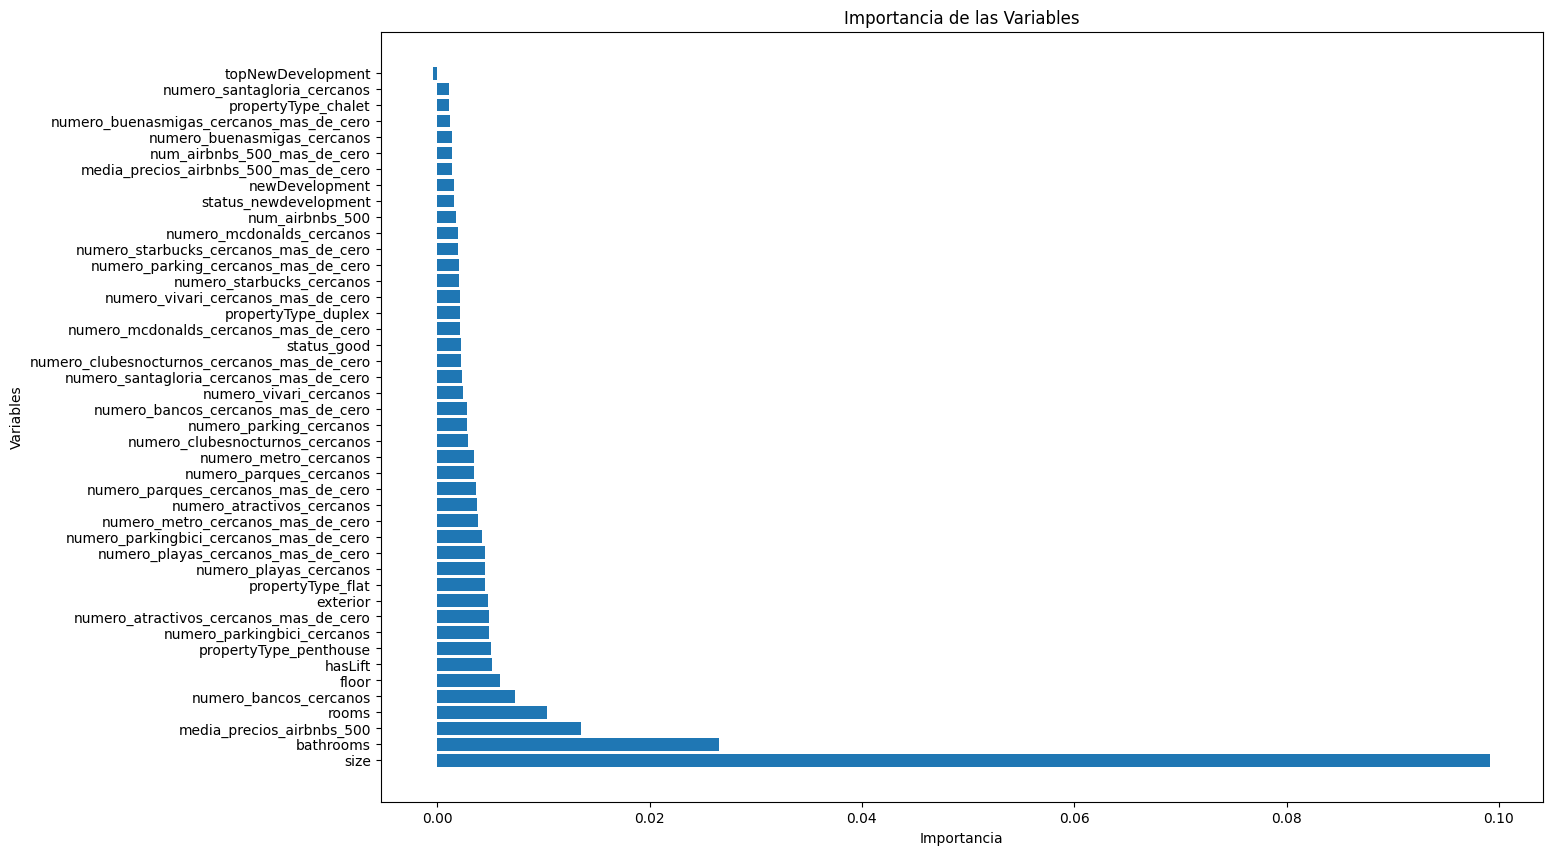

In [20]:


# Supongamos que tienes los nombres de las columnas en una lista
# Si X_train es un DataFrame de pandas, puedes usar X_train.columns
nombres_variables = X_train.columns  # Si es un DataFrame, si no, usa una lista con los nombres.

# Evaluamos la importancia de las variables
resultados = permutation_importance(svr_model, X_test_scaled, y_test, n_repeats=10, random_state=42, scoring='neg_mean_squared_error')

# Obtenemos la importancia de cada variable
importances = resultados.importances_mean

# Ordenamos las importancias de menor a mayor
indices_ordenados = np.argsort(importances)[::-1]
importances_ordenadas = importances[indices_ordenados]
variables_ordenadas = nombres_variables[indices_ordenados]

# Graficamos la importancia de las variables de forma vertical (barras horizontales)
plt.figure(figsize=(15, 10))
plt.barh(range(len(importances_ordenadas)), importances_ordenadas, tick_label=variables_ordenadas)
plt.ylabel('Variables')
plt.xlabel('Importancia')
plt.title('Importancia de las Variables')
plt.show()




## Residuos

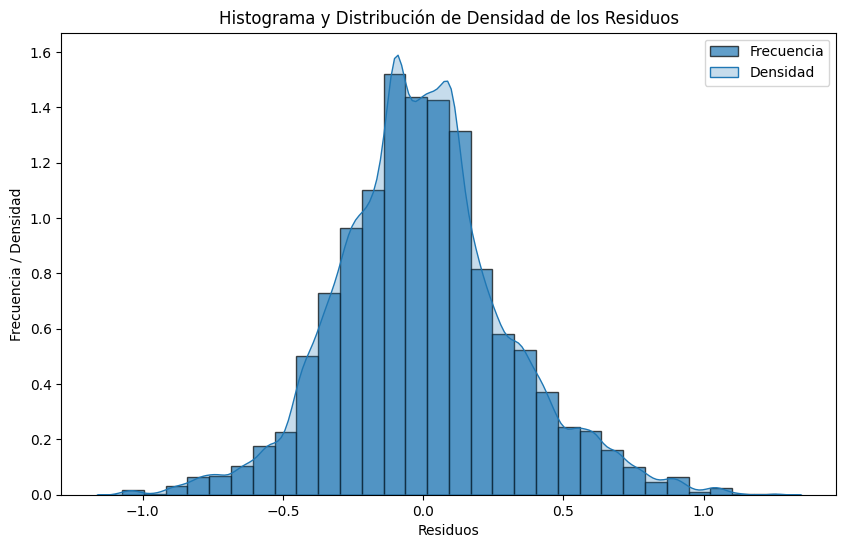

In [22]:
# Calculamos los residuos
residuals = y_test - y_pred


# Creamos una figura de tamaño 10x6
plt.figure(figsize=(10, 6))

# Graficamos el histograma de los residuos
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7, label='Frecuencia', density=True)

# Graficamos la densidad de los residuos
sns.kdeplot(residuals, bw_adjust=0.5, fill=True, label='Densidad')

# Añadimos título y etiquetas
plt.title('Histograma y Distribución de Densidad de los Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia / Densidad')

# Añadimos la leyenda para distinguir ambas gráficas
plt.legend()

# Mostramos el gráfico
plt.show()



## Q-Q Plot

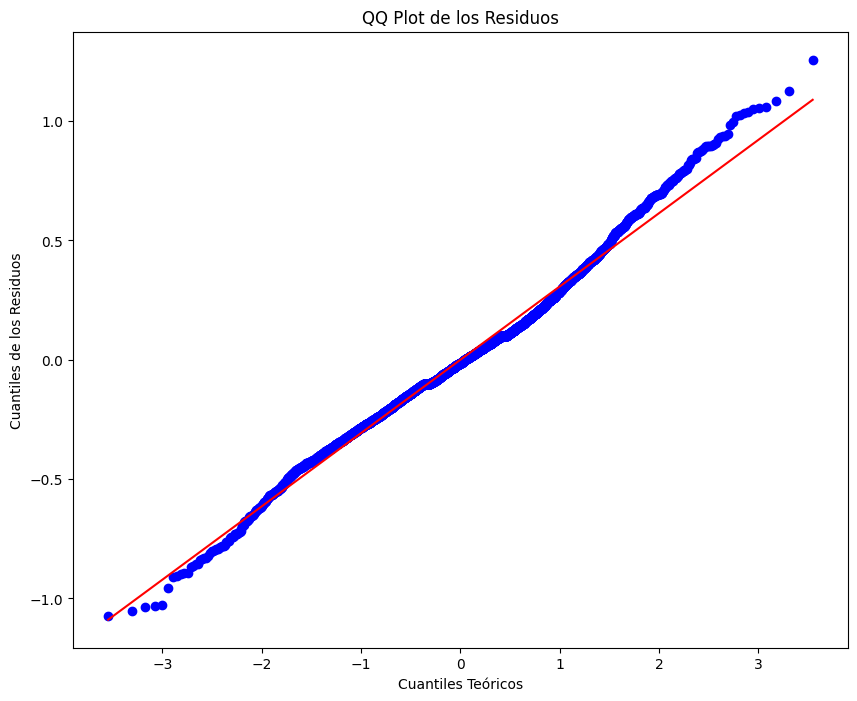

In [11]:


# Creamos la gráfica
plt.figure(figsize=(10, 8))

# Graficamos el QQ plot
stats.probplot(residuals, dist="norm", plot=plt)


plt.title('QQ Plot de los Residuos')
plt.xlabel('Cuantiles Teóricos')
plt.ylabel('Cuantiles de los Residuos')

# Mostramos el gráfico
plt.show()

# **Modelo Variable dependiente "log_price_m2"**

In [6]:
#Separamos variables independientes y variable dependiente
X = data[['floor', 'size', 'exterior', 'rooms', 'bathrooms', 'newDevelopment', 'hasLift', 'topNewDevelopment',
    'numero_bancos_cercanos', 'numero_starbucks_cercanos', 'numero_atractivos_cercanos', 'numero_buenasmigas_cercanos',
    'numero_clubesnocturnos_cercanos', 'numero_mcdonalds_cercanos', 'numero_metro_cercanos', 'numero_parking_cercanos',
    'numero_parkingbici_cercanos', 'numero_parques_cercanos', 'numero_playas_cercanos', 'numero_santagloria_cercanos',
    'numero_vivari_cercanos', 'num_airbnbs_500', 'media_precios_airbnbs_500',
    'propertyType_chalet', 'propertyType_duplex', 'propertyType_flat', 'propertyType_penthouse', 'status_good',
    'status_newdevelopment', 'num_airbnbs_500_mas_de_cero', 'media_precios_airbnbs_500_mas_de_cero',
    'numero_bancos_cercanos_mas_de_cero', 'numero_starbucks_cercanos_mas_de_cero', 'numero_atractivos_cercanos_mas_de_cero',
    'numero_buenasmigas_cercanos_mas_de_cero', 'numero_clubesnocturnos_cercanos_mas_de_cero', 'numero_mcdonalds_cercanos_mas_de_cero',
    'numero_metro_cercanos_mas_de_cero', 'numero_parking_cercanos_mas_de_cero', 'numero_parkingbici_cercanos_mas_de_cero',
    'numero_parques_cercanos_mas_de_cero', 'numero_playas_cercanos_mas_de_cero', 'numero_santagloria_cercanos_mas_de_cero',
    'numero_vivari_cercanos_mas_de_cero']]
y = data['log_price_m2']

## División datos para entrenamiento y prueba

In [ ]:
from sklearn.model_selection import train_test_split

#Dividimos el dataset en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Escalamiento de variables y entrenamiento SVR

In [ ]:
#Escalamiento de variables
from sklearn.preprocessing import StandardScaler

#Definimos el escalador
scaler = StandardScaler()

#Datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

#Datos de prueba
X_test_scaled = scaler.transform(X_test)

#Entrenamiento modelo SVR
from sklearn.svm import SVR

#Creamos el modelo SVR con el kernel RBF
svr_model = SVR(kernel='rbf')

#Entrenamos el modelo
svr_model.fit(X_train_scaled, y_train)

#Predicciones
#Predecimos los precios en los datos de prueba
y_pred = svr_model.predict(X_test_scaled)

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Supongamos que X_train, X_test, y_train están definidos

# Escalamiento de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenamiento del modelo SVR
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train)

# Predicciones en los datos de entrenamiento
y_train_pred = svr_model.predict(X_train_scaled)

# Cálculo de MAE (Error Absoluto Medio)
mae = mean_absolute_error(y_train, y_train_pred)
print(f"MAE: {mae:.4f}")

# Cálculo de MAPE (Error Porcentual Absoluto Medio)
mape = mean_absolute_percentage_error(y_train, y_train_pred) * 100
print(f"MAPE: {mape:.4f}%")

# Cálculo de R^2 (Coeficiente de Determinación)
r2 = r2_score(y_train, y_train_pred)
print(f"R^2: {r2:.4f}")

# Cálculo de R^2 Ajustado
n = len(y_train)  # Número de observaciones
p = X_train_scaled.shape[1]  # Número de variables
r2_adjusted = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f"R^2 Ajustado: {r2_adjusted:.4f}")

# Aproximación del AIC
aic = n * np.log(mae) + 2 * p
print(f"AIC (aproximado): {aic:.4f}")


MAE: 0.2114
MAPE: 2.7373%
R^2: 0.6741
R^2 Ajustado: 0.6731
AIC (aproximado): -21904.3141


## Evaluación del modelo

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import numpy as np


#Calculo de MSE
mse = mean_squared_error(y_test, y_pred)

#Calculamos el R²
r2 = r2_score(y_test, y_pred)

#Calculamos el R² ajustado
n = len(y_test)
p = X_test.shape[1]
r2_ajustado = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Calculamos MAE
mae = mean_absolute_error(y_test, y_pred)

#Calculamos MAPE
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

#Suma de Residuos al Cuadrado (RSS)
rss = np.sum((y_test - y_pred) ** 2)

#Calculamos el AIC
aic = n * np.log(rss / n) + 2 * p

print(f'MSE : {mse}')
print(f'R² : {r2}')
print(f'R² ajustado : {r2_ajustado}')
print(f'MAE : {mae}')
print(f'MAPE : {mape:.2f}%')
print(f'AIC : {aic}')

MSE : 0.09524437433225318
R² : 0.6144668111562099
R² ajustado : 0.6096103953791912
MAE : 0.23550724216963861
MAPE : 3.05%
AIC : -8230.932405464715


## Ajuste de Hiperparametros

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import GridSearchCV
import numpy as np

# Definir los parámetros a ajustar
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

#Creamos el modelo de búsqueda en cuadrícula
grid = GridSearchCV(SVR(), param_grid, refit=True, verbose=2)

#Entrenamos el modelo con búsqueda de hiperparámetros
grid.fit(X_train_scaled, y_train)

#Mejoramos combinación de parámetros
print("Mejores parámetros encontrados:", grid.best_params_)


best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

#Métricas
r2 = r2_score(y_test, y_pred_best)
mae = mean_absolute_error(y_test, y_pred_best)
mape = mean_absolute_percentage_error(y_test, y_pred_best)

#Calculamos el R2 ajustado
n = len(y_test)
p = X_test_scaled.shape[1]
r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Calculamos AIC

rss = np.sum((y_test - y_pred_best) ** 2)
aic = n * np.log(rss / n) + 2 * p

# Imprimir métricas
print("R2:", r2)
print("R2 Ajustado:", r2_adj)
print("MAE:", mae)
print("MAPE:", mape)
print("AIC:", aic)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  11.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  10.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  11.4s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  10.9s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=  10.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   7.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   8.2s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   6.9s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   8.1s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   8.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   7.2s
[CV] END ......................C=0.1, gamma=0.01

## Importancia de las variables

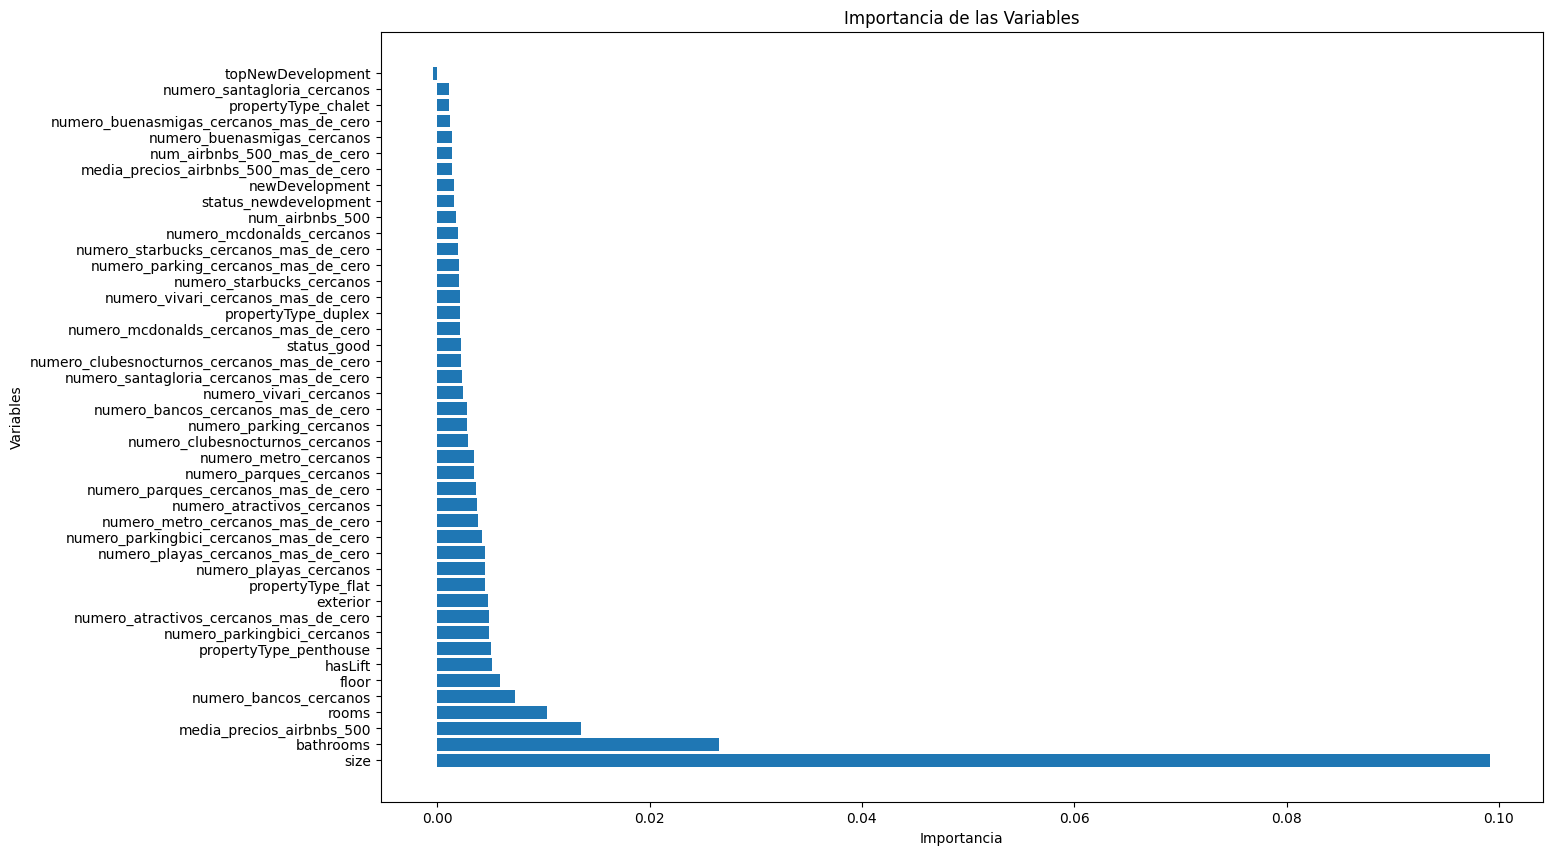

In [ ]:


# Supongamos que tienes los nombres de las columnas en una lista
# Si X_train es un DataFrame de pandas, puedes usar X_train.columns
nombres_variables = X_train.columns  # Si es un DataFrame, si no, usa una lista con los nombres.

# Evaluamos la importancia de las variables
resultados = permutation_importance(svr_model, X_test_scaled, y_test, n_repeats=10, random_state=42, scoring='neg_mean_squared_error')

# Obtenemos la importancia de cada variable
importances = resultados.importances_mean

# Ordenamos las importancias de menor a mayor
indices_ordenados = np.argsort(importances)[::-1]
importances_ordenadas = importances[indices_ordenados]
variables_ordenadas = nombres_variables[indices_ordenados]

# Graficamos la importancia de las variables de forma vertical (barras horizontales)
plt.figure(figsize=(15, 10))
plt.barh(range(len(importances_ordenadas)), importances_ordenadas, tick_label=variables_ordenadas)
plt.ylabel('Variables')
plt.xlabel('Importancia')
plt.title('Importancia de las Variables')
plt.show()




## Residuos

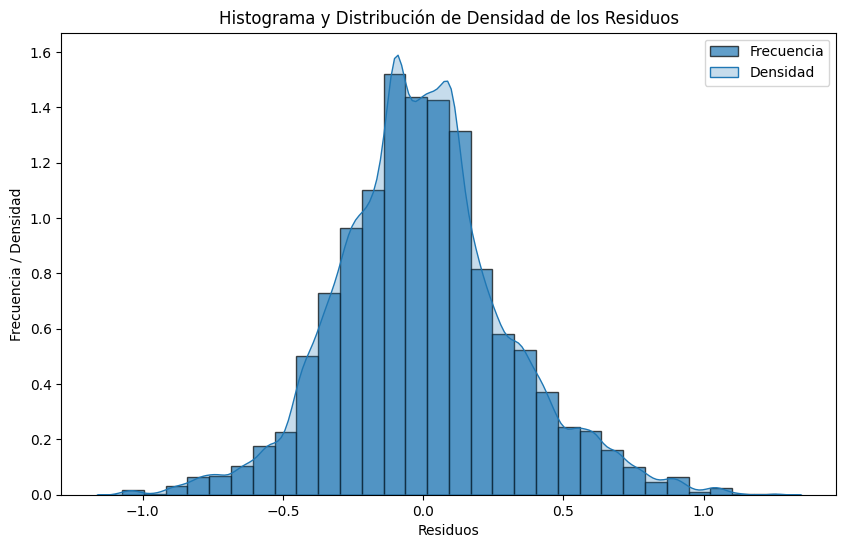

In [ ]:
# Calculamos los residuos
residuals = y_test - y_pred


# Creamos una figura de tamaño 10x6
plt.figure(figsize=(10, 6))

# Graficamos el histograma de los residuos
plt.hist(residuals, bins=30, edgecolor='k', alpha=0.7, label='Frecuencia', density=True)

# Graficamos la densidad de los residuos
sns.kdeplot(residuals, bw_adjust=0.5, fill=True, label='Densidad')

# Añadimos título y etiquetas
plt.title('Histograma y Distribución de Densidad de los Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia / Densidad')

# Añadimos la leyenda para distinguir ambas gráficas
plt.legend()

# Mostramos el gráfico
plt.show()



## Q-Q Plot

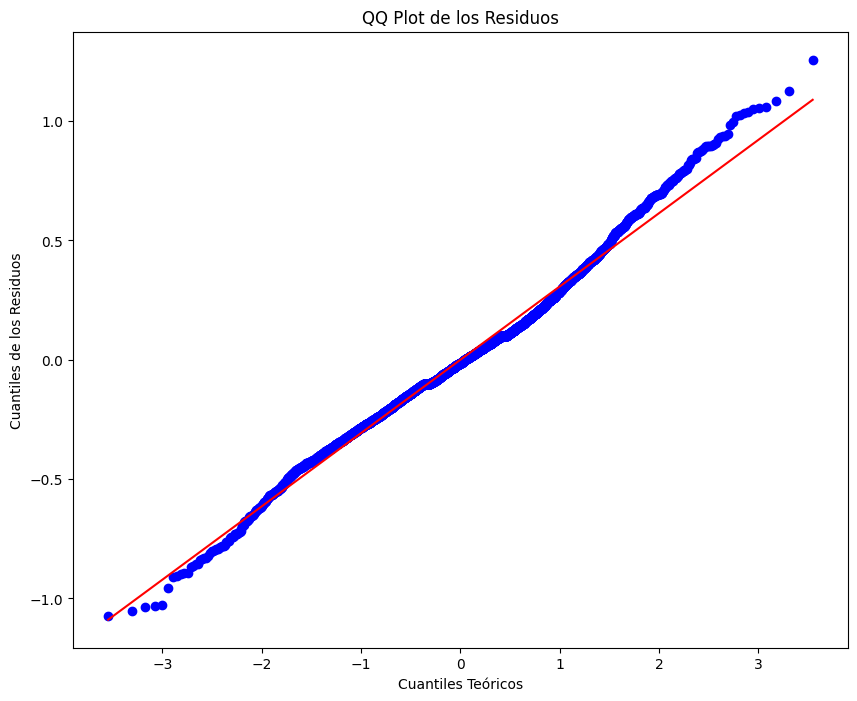

In [ ]:


# Creamos la gráfica
plt.figure(figsize=(10, 8))

# Graficamos el QQ plot
stats.probplot(residuals, dist="norm", plot=plt)


plt.title('QQ Plot de los Residuos')
plt.xlabel('Cuantiles Teóricos')
plt.ylabel('Cuantiles de los Residuos')

# Mostramos el gráfico
plt.show()